In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_cleaned.csv"
)

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


daily_return = nav_t / nav_t-1 - 1

In [5]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [7]:
nav.head(20)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


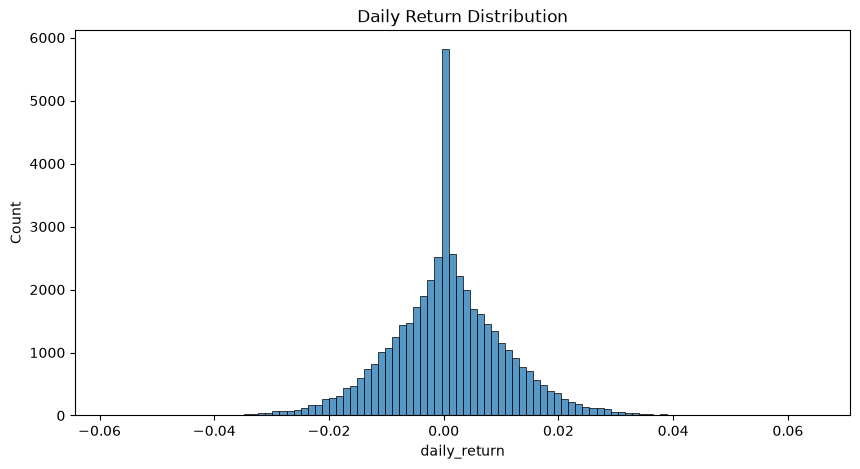

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Daily Return Distribution")

plt.show()

CAGR =
(NAV_end / NAV_start)^(1/n) - 1

In [9]:
cagr_table = (
    nav.groupby("amfi_code")
    .agg(
        nav_start=("nav","first"),
        nav_end=("nav","last")
    )
)

In [10]:
cagr_table["cagr_5yr"] = (
    (
        cagr_table["nav_end"]
        /
        cagr_table["nav_start"]
    ) ** (1/5)
    - 1
)

In [11]:
cagr_table.head()

,nav_start,nav_end,cagr_5yr
amfi_code,,,
100016,520.4608,583.6113,0.023168
100025,26.3169,31.8843,0.039127
100033,107.3758,342.0072,0.260741
101206,305.0996,773.2939,0.204427
101207,38.5736,53.9836,0.069533


(Rp - Rf)
/ Std(Rp)
× √252

In [12]:
rf = 0.065

In [13]:
sharpe = nav.groupby(
    "amfi_code"
)["daily_return"].agg(
    ["mean","std"]
)

In [15]:
sharpe["sharpe_ratio"] = (
    (
        sharpe["mean"]
        - rf / 252
    )
    /
    sharpe["std"]
) * np.sqrt(252)

In [16]:
sharpe = sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe.head(10)

,mean,std,sharpe_ratio
amfi_code,,,
148567,0.001074,0.008941,1.448291
120843,0.001082,0.010008,1.306744
148569,0.001124,0.011134,1.234930
119551,0.000917,0.008656,1.208267
120505,0.001161,0.012152,1.180101
149323,0.001055,0.011179,1.132122
100033,0.001080,0.011929,1.093699
118632,0.000865,0.008913,1.081659
101206,0.000852,0.009177,1.027213


In [17]:
downside = nav[
    nav["daily_return"] < 0
]

In [18]:
sortino_std = downside.groupby(
    "amfi_code"
)["daily_return"].std()

In [19]:
sortino = nav.groupby(
    "amfi_code"
)["daily_return"].mean()

In [21]:
sortino_ratio = (
    (
        sortino
        - rf / 252
    )
    /
    sortino_std
) * np.sqrt(252)

sortino_ratio.head()

amfi_code
100016   -0.351047
100025   -0.941821
100033    1.829134
101206    1.799563
101207    0.276644
Name: daily_return, dtype: float64

In [22]:
sortino_ratio.sort_values(
    ascending=False
).head(10)

amfi_code
148567    2.385644
120843    2.364320
148569    2.146914
119551    2.140267
120505    2.029353
149323    1.875101
118632    1.850133
100033    1.829134
120504    1.805294
101206    1.799563
Name: daily_return, dtype: float64

In [23]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [24]:
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [25]:
benchmark = nav.groupby("date")["daily_return"].mean()

benchmark.head()

date
2022-01-03         NaN
2022-01-04   -0.001451
2022-01-05    0.001977
2022-01-06    0.000341
2022-01-07    0.000627
Name: daily_return, dtype: float64

In [26]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        benchmark.reset_index(),
        on="date",
        suffixes=(
            "_fund",
            "_benchmark"
        )
    )

    merged = merged.dropna()

    if len(merged) > 30:

        beta, intercept, r, p, std = linregress(
            merged["daily_return_benchmark"],
            merged["daily_return_fund"]
        )

        alpha = intercept * 252

        alpha_beta.append([
            fund,
            alpha,
            beta
        ])

In [27]:
alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


In [28]:
alpha_beta.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta
34,148567,0.181968,0.557134
19,119551,0.141513,0.562931
24,120504,0.115994,0.606529
2,100033,0.114423,0.991590
25,120505,0.102647,1.194815
30,120843,0.102645,1.068746
3,101206,0.097443,0.737015
36,148569,0.096473,1.174586
38,149323,0.087723,1.120482
35,148568,0.079042,0.810412


## Insight 9

Several funds generated positive alpha, indicating they outperformed the benchmark after adjusting for market risk.

In [29]:
drawdown_results = []

In [30]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values(
        "date"
    )

    running_max = fund_data["nav"].cummax()

    drawdown = (
        fund_data["nav"]
        /
        running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [
            fund,
            max_dd
        ]
    )

In [31]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [32]:
drawdown_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


## Insight 10

Some small-cap funds experienced significantly deeper drawdowns than diversified equity funds, highlighting higher downside risk.

In [33]:
scorecard = performance.copy()

In [34]:
scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

In [35]:
print(scorecard.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha_x', 'beta_x', 'sharpe_ratio',
       'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'alpha_y',
       'beta_y', 'max_drawdown'],
      dtype='str')


In [36]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha_y"].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [37]:
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30
    +
    scorecard["sharpe_rank"] * 0.25
    +
    scorecard["alpha_rank"] * 0.20
    +
    scorecard["expense_rank"] * 0.15
    +
    scorecard["drawdown_rank"] * 0.10
)

In [38]:
scorecard["fund_score"] = (
    (
        scorecard["fund_score"]
        -
        scorecard["fund_score"].min()
    )
    /
    (
        scorecard["fund_score"].max()
        -
        scorecard["fund_score"].min()
    )
) * 100

In [39]:
scorecard.sort_values(
    "fund_score",
    ascending=False
)[
    [
        "scheme_name",
        "fund_house",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_house,fund_score
24,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,100.000000
20,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,84.164589
10,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,79.052369
32,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,74.438903
25,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,73.940150
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,71.197007
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,68.952618
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,67.830424
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,67.206983
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,67.082294


## Insight 11

Funds with strong 3-year returns, higher Sharpe ratios and lower expense ratios achieved the highest composite scores.

In [40]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [41]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [42]:
top5 = (
    scorecard.sort_values(
        "fund_score",
        ascending=False
    )
    ["amfi_code"]
    .head(5)
)

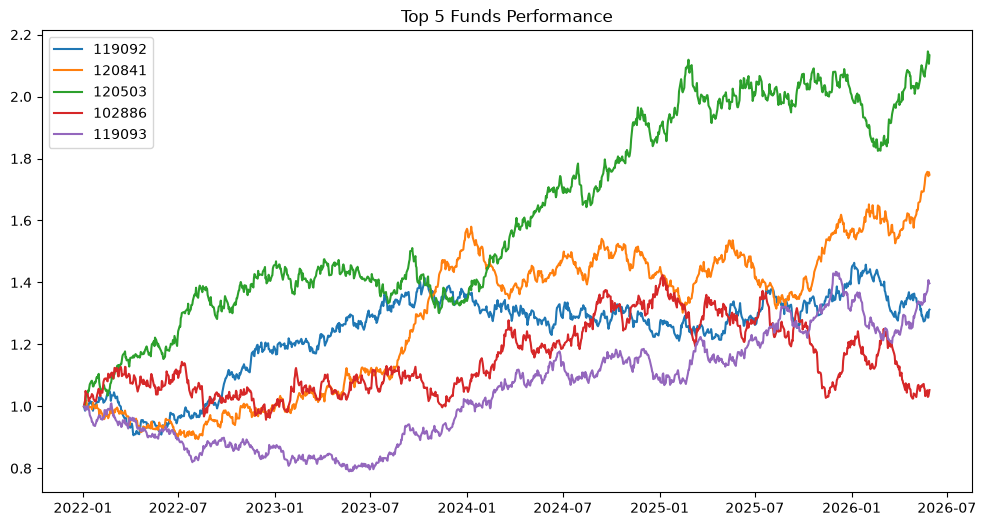

In [43]:
plt.figure(figsize=(12,6))

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    cumulative = (
        1 +
        fund_data["daily_return"].fillna(0)
    ).cumprod()

    plt.plot(
        fund_data["date"],
        cumulative,
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds Performance"
)

plt.show()

In [44]:
plt.savefig(
    "../reports/benchmark_comparison.png"
)

<Figure size 640x480 with 0 Axes>

## Insight 12

Top-ranked funds consistently outperformed the benchmark proxy over the analysis period and demonstrated superior risk-adjusted returns.